In [ ]:
from transformers import GPT2Model, GPT2Tokenizer, BertModel, BertTokenizer

In [4]:
gpt2 = GPT2Model.from_pretrained("gpt2")
gpt2_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

bert = BertModel.from_pretrained("bert-base-uncased")
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [5]:
print(gpt2)
print(bert)

GPT2Model(
  (wte): Embedding(50257, 768)
  (wpe): Embedding(1024, 768)
  (drop): Dropout(p=0.1, inplace=False)
  (h): ModuleList(
    (0-11): 12 x GPT2Block(
      (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (attn): GPT2Attention(
        (c_attn): Conv1D(nf=2304, nx=768)
        (c_proj): Conv1D(nf=768, nx=768)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (mlp): GPT2MLP(
        (c_fc): Conv1D(nf=3072, nx=768)
        (c_proj): Conv1D(nf=768, nx=3072)
        (act): NewGELUActivation()
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
)
BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (La

In [33]:
gtp2E = gpt2.wte.weight.detach()

print("GPT2: Embedding shape", gtp2E.shape)
print("GPT2: Vocab size", gpt2_tokenizer.vocab_size)

bertE = bert.embeddings.word_embeddings.weight.detach()
print("BERT: Embedding shape", bertE.shape)
print("BERT: Vocab size", bert_tokenizer.vocab_size)

max_dim = bertE.max()
print(max_dim)

GPT2: Embedding shape torch.Size([50257, 768])
GPT2: Vocab size 50257
BERT: Embedding shape torch.Size([30522, 768])
BERT: Vocab size 30522
tensor(0.8729)


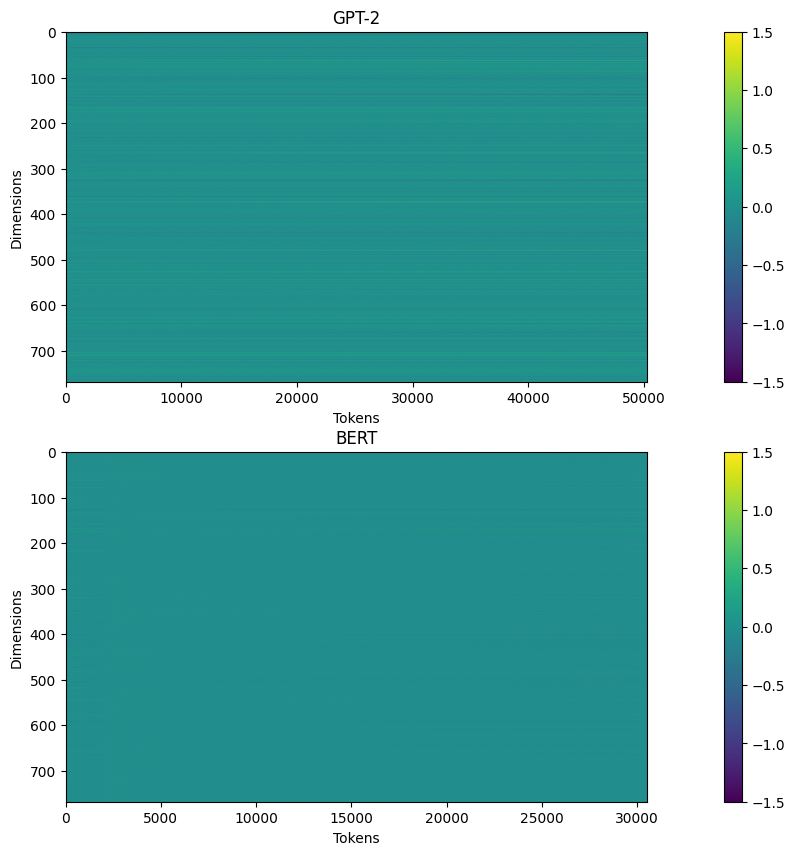

In [36]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 1, figsize=(10, 10))
h = axs[0].imshow(gtp2E.T, aspect="auto", vmin=-1.5, vmax=1.5)
axs[0].set(xlabel="Tokens", ylabel = "Dimensions", title="GPT-2")
fig.colorbar(h, ax=axs[0], pad=0.1)

h = axs[1].imshow(bertE.T, aspect="auto", vmin=-1.5, vmax=1.5)
axs[1].set(xlabel="Tokens", ylabel = "Dimensions", title="BERT")
fig.colorbar(h, ax=axs[1], pad=0.1)
plt.show()

21345.18526657195
2265.321689294163


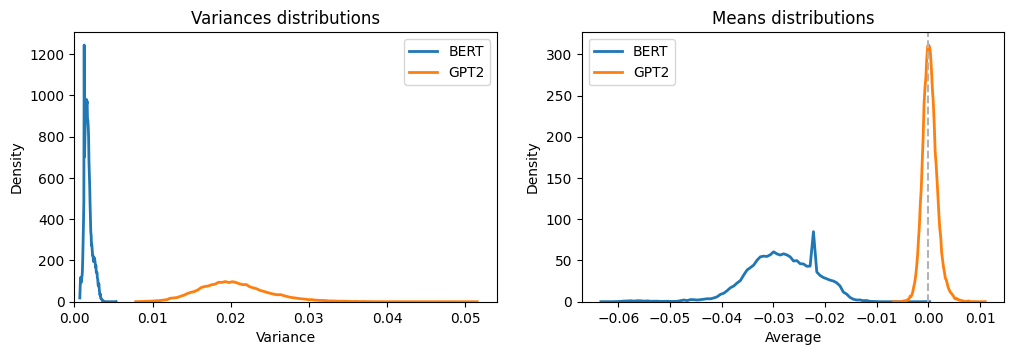

In [ ]:
import numpy as np
_,axs = plt.subplots(1,2,figsize=(12,3.5))

# compare the embeddings variances
yB,xB = np.histogram(bertE.var(axis=1),bins=100, density=True)
# print(yB.sum())
yG,xG = np.histogram(gtp2E.var(axis=1),bins=100, density=True)
# print(yG.sum())

axs[0].plot(xB[:-1],yB,linewidth=2,label='BERT')
axs[0].plot(xG[:-1],yG,linewidth=2,label='GPT2')
axs[0].set(xlabel='Variance',ylabel='Density',xlim=[0,None],ylim=[0,None],title='Variances distributions')
axs[0].legend()

# compare the embeddings means
yB,xB = np.histogram(bertE.mean(axis=1),bins=100,density=True)
yG,xG = np.histogram(gtp2E.mean(axis=1),bins=100,density=True)

axs[1].plot(xB[:-1],yB,linewidth=2,label='BERT')
axs[1].plot(xG[:-1],yG,linewidth=2,label='GPT2')
axs[1].axvline(0,color=[.7,.7,.7],linestyle='--')
axs[1].set(xlabel='Average',ylabel='Density',ylim=[0,None],title='Means distributions')
axs[1].legend()


plt.show()

In [65]:
geptEmbNpP = gtp2E.numpy()
t3 = gpt2_tokenizer.encode("3")
t5 = gpt2_tokenizer.encode("5")
e3 = geptEmbNpP[t3, :].squeeze()
e5 = geptEmbNpP[t5, :].squeeze()

# print(e3.shape)
# print(e5.shape)

sum35 = e3 + e5
prod35 = e3 * e5

print("sum35 shape: ", sum35.shape)
print("prod35 shape: ", prod35.shape)
print("geptEmbNpP.T shape: ", geptEmbNpP.T.shape)

sum35UnEmbed = sum35 @ geptEmbNpP.T
prod35UnEmbed = prod35 @ geptEmbNpP.T

print("sum35UnEmbed shape: ", sum35UnEmbed.shape)
print("prod35UnEmbed shape: ", prod35UnEmbed.shape)

print(f"Max embedding of 5 + 3: {sum35UnEmbed.max()} at pos {sum35UnEmbed.argmax()} => decoded to {gpt2_tokenizer.decode(sum35UnEmbed.argmax())}")
print(f"Max embedding of 5 x 3: {prod35UnEmbed.max()} at pos {prod35UnEmbed.argmax()} => decoded to {gpt2_tokenizer.decode(prod35UnEmbed.argmax())}")





sum35 shape:  (768,)
prod35 shape:  (768,)
geptEmbNpP.T shape:  (768, 50257)
sum35UnEmbed shape:  (50257,)
prod35UnEmbed shape:  (50257,)
Max embedding of 5 + 3: 15.017386436462402 at pos 20 => decoded to 5
Max embedding of 5 x 3: 0.02224745601415634 at pos 22473 => decoded to  Weinstein
